# Box-Toeplitz Active Block Experiments

这个 notebook 现在同时承担两件事：

1. 直接在 cell 里配置 BTAB / EigenPro / plain CG 的实验参数；
2. 运行 `run_experiments.py` 里的同一套实验逻辑，并自动汇总、画图。

当前 BTAB 已同时支持两种 box solve 模式：

- `exact`：显式构造 dense `A_g` 并做 Cholesky；
- `inner_pcg`：matrix-free local Toeplitz apply + inner PCG；
- `auto`：按 `exact_box_max_size` 自动切换。

这个 notebook 也支持一整套 `GitHub -> Colab -> Google Drive` 工作流：

- 在 Colab 中自动 clone / pull 仓库；
- 安装运行所需依赖；
- 从 Google Drive 恢复缺失的 `.npz` 数据；
- 把当前 run 的输出和 notebook 一起打包导出回 Drive。

推荐使用顺序：

1. 先运行 `Colab / Drive setup`；
2. 再运行 `GitHub import / package install`；
3. 修改参数后运行实验或读取已有结果；
4. 最后运行 `Colab export / download / disconnect` 做备份。

如果你不想重新跑，只想读以前的结果，把 `RUN_EXPERIMENT = False` 即可。

In [ ]:
# ---- Optional Colab / Drive setup ----617
# 本地运行时不会触发挂载；在 Colab 中默认启用 Drive，便于恢复 .npz 数据和导出结果 bundle。
import sys
import time
from pathlib import Path

start_time = time.time()
IS_COLAB = "google.colab" in sys.modules

ENABLE_COLAB_DRIVE = True

DRIVE_MOUNT_DIR = Path("/content/drive")
DRIVE_MYDRIVE_DIR = DRIVE_MOUNT_DIR / "MyDrive"
DRIVE_CACHE_ENABLED = bool(IS_COLAB and ENABLE_COLAB_DRIVE)
DRIVE_CACHE_SEARCH_RECURSIVE = True
DRIVE_CACHE_CANDIDATE_DIRS = [
    DRIVE_MYDRIVE_DIR / "EFGP_Eigenpro" / "benchmark_dataset_cache",
    DRIVE_MYDRIVE_DIR / "Colab_Experiments" / "EFGP_Eigenpro" / "benchmark_dataset_cache",
    DRIVE_MYDRIVE_DIR / "benchmark_dataset_cache",
    DRIVE_MYDRIVE_DIR,
]
DRIVE_OUTPUT_DIR = DRIVE_MYDRIVE_DIR / "EFGP_Eigenpro" / "benchmark_exports"

DRIVE_MOUNTED = False
if IS_COLAB and ENABLE_COLAB_DRIVE:
    try:
        from google.colab import drive
        if not DRIVE_MYDRIVE_DIR.exists():
            drive.mount(str(DRIVE_MOUNT_DIR))
        DRIVE_MOUNTED = DRIVE_MYDRIVE_DIR.exists()
    except Exception as e:
        print("Drive mount skipped:", e)
else:
    if IS_COLAB:
        print("[note] Colab detected, but Drive mount is disabled (ENABLE_COLAB_DRIVE=False)")

print("IS_COLAB:", IS_COLAB)
print("ENABLE_COLAB_DRIVE:", ENABLE_COLAB_DRIVE)
print("DRIVE_MOUNTED:", DRIVE_MOUNTED)
print("DRIVE_MYDRIVE_DIR:", DRIVE_MYDRIVE_DIR)
print("DRIVE_CACHE_ENABLED:", DRIVE_CACHE_ENABLED)
print("DRIVE_OUTPUT_DIR:", DRIVE_OUTPUT_DIR)


In [ ]:
## For GitHub import

# ---- Optional GitHub import / package install ----
# 在 Colab 中默认启用：clone/pull 仓库、安装依赖、切到当前 notebook 目录，并打印 GitHub / Colab 链接。
import os
import subprocess
import sys
from pathlib import Path

IS_COLAB = "google.colab" in sys.modules
ENABLE_COLAB_GITHUB_INSTALL = True

GITHUB_USER = "Yifiwifi"
REPO_NAME = "EFGP-Eigenpro"
GITHUB_BRANCH = "main"
SUB_DIR = "efgp_eigenpro_py"
NOTEBOOK_REL_PATH = "efgp_eigenpro_py/gpu/box_toeplitz_active_block/report_results.ipynb"
NOTEBOOK_DIR_REL = "efgp_eigenpro_py/gpu/box_toeplitz_active_block"
PROJECT_PATH = Path(f"/content/{REPO_NAME}")
REPO_URL = f"https://github.com/{GITHUB_USER}/{REPO_NAME}.git"
GITHUB_NOTEBOOK_URL = f"https://github.com/{GITHUB_USER}/{REPO_NAME}/blob/{GITHUB_BRANCH}/{NOTEBOOK_REL_PATH}"
COLAB_NOTEBOOK_URL = (
    f"https://colab.research.google.com/github/{GITHUB_USER}/{REPO_NAME}"
    f"/blob/{GITHUB_BRANCH}/{NOTEBOOK_REL_PATH}"
)


def _run_cmd(args: list[str], *, cwd: Path | None = None) -> None:
    print("+", " ".join(str(a) for a in args))
    subprocess.run(args, check=True, cwd=None if cwd is None else str(cwd))


if IS_COLAB and ENABLE_COLAB_GITHUB_INSTALL:
    if not PROJECT_PATH.exists():
        _run_cmd(["git", "clone", REPO_URL, str(PROJECT_PATH)])
    else:
        _run_cmd(["git", "pull", "origin", GITHUB_BRANCH], cwd=PROJECT_PATH)

    os.chdir(PROJECT_PATH)

    CODE_ROOT = PROJECT_PATH / SUB_DIR
    REPO_ROOT = PROJECT_PATH
    NOTEBOOK_DIR_PATH = PROJECT_PATH / NOTEBOOK_DIR_REL

    if str(REPO_ROOT) not in sys.path:
        sys.path.insert(0, str(REPO_ROOT))
    if str(CODE_ROOT) not in sys.path:
        sys.path.insert(0, str(CODE_ROOT))

    print("Installing runtime dependencies")
    _run_cmd([
        sys.executable,
        "-m",
        "pip",
        "install",
        "cufinufft",
        "cupy-cuda12x",
        "--extra-index-url",
        "https://pypi.nvidia.com",
    ])
    _run_cmd([sys.executable, "-m", "pip", "install", "git+https://github.com/EigenPro/EigenPro3.git"])
    _run_cmd([sys.executable, "-m", "pip", "install", "git+https://github.com/EigenPro/EigenPro-pytorch.git"])

    requirements_path = CODE_ROOT / "requirements.txt"
    if requirements_path.exists():
        _run_cmd([sys.executable, "-m", "pip", "install", "-r", str(requirements_path)])

    if NOTEBOOK_DIR_PATH.exists():
        os.chdir(NOTEBOOK_DIR_PATH)
        print("cwd:", os.getcwd())
    else:
        print("notebook dir not found:", NOTEBOOK_DIR_PATH)

    os.environ["LD_LIBRARY_PATH"] = "/usr/local/lib:" + os.environ.get("LD_LIBRARY_PATH", "")
    try:
        _run_cmd(["ldconfig", "/usr/local/lib"])
    except Exception as e:
        print("ldconfig skipped:", e)

    print("=" * 40)
    try:
        import torch
        import cupy as cp
        import cufinufft
        import eigenpro2
        import eigenpro3

        cp.cuda.Stream.null.synchronize()
        print("PyTorch:", torch.__version__)
        if torch.cuda.is_available():
            print("GPU:", torch.cuda.get_device_name(0))
        else:
            print("GPU: cuda unavailable")
        print("cufinufft / eigenpro2 / eigenpro3 import ok")
    except Exception as e:
        print("runtime check failed:", e)
    print("=" * 40)
else:
    print(
        "[note] GitHub/Colab install cell skipped (IS_COLAB=", IS_COLAB,
        ", ENABLE_COLAB_GITHUB_INSTALL=", ENABLE_COLAB_GITHUB_INSTALL, ")"
    )

print("GitHub notebook URL:", GITHUB_NOTEBOOK_URL)
print("Open in Colab URL:", COLAB_NOTEBOOK_URL)


In [64]:
from pathlib import Path
from datetime import datetime
import sys
import json
import importlib
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import HTML, display

NOTEBOOK_ROOT = Path.cwd().resolve()
SEARCH_ROOTS = [
    NOTEBOOK_ROOT,
    *NOTEBOOK_ROOT.parents,
    Path("/content/EFGP-Eigenpro"),
    Path("/content"),
    Path("D:/NU/ML"),
]
_seen = set()
SEARCH_ROOTS = [p for p in SEARCH_ROOTS if not (str(p) in _seen or _seen.add(str(p)))]
REPO_ROOT = next((p for p in SEARCH_ROOTS if (p / "efgp_eigenpro_py").exists()), None)
if REPO_ROOT is None:
    raise FileNotFoundError(
        "Could not locate repo root containing 'efgp_eigenpro_py'. "
        f"Started from: {NOTEBOOK_ROOT}; searched: {[str(p) for p in SEARCH_ROOTS]}"
    )
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)
pd.set_option("display.expand_frame_repr", False)


def display_full_df(df: pd.DataFrame) -> None:
    display(HTML(df.to_html(max_rows=None, max_cols=None, escape=False)))


BTAB_MODULES = [
    "efgp_eigenpro_py.gpu.iterative_solvers",
    "efgp_eigenpro_py.gpu.box_toeplitz_active_block.active_set",
    "efgp_eigenpro_py.gpu.box_toeplitz_active_block.config",
    "efgp_eigenpro_py.gpu.box_toeplitz_active_block.preconditioner",
    "efgp_eigenpro_py.gpu.box_toeplitz_active_block.runner",
    "efgp_eigenpro_py.gpu.versions",
    "efgp_eigenpro_py.gpu.box_toeplitz_active_block.run_experiments",
]


def reload_btab_modules():
    reloaded = {}
    for name in BTAB_MODULES:
        mod = importlib.import_module(name)
        reloaded[name] = importlib.reload(mod)
    return reloaded


reloaded_mods = reload_btab_modules()
config_mod = reloaded_mods["efgp_eigenpro_py.gpu.box_toeplitz_active_block.config"]
run_mod = reloaded_mods["efgp_eigenpro_py.gpu.box_toeplitz_active_block.run_experiments"]

BTABExperimentConfig = config_mod.BTABExperimentConfig
discover_processed_datasets = run_mod.discover_processed_datasets
run_experiments = run_mod.run_experiments

OUTPUT_CANDIDATES = [
    NOTEBOOK_ROOT / "outputs",
    REPO_ROOT / "efgp_eigenpro_py" / "gpu" / "box_toeplitz_active_block" / "outputs",
]
OUT_ROOT = next((p for p in OUTPUT_CANDIDATES if p.exists()), OUTPUT_CANDIDATES[-1])
PROCESSED_DATA_DIR = REPO_ROOT / "efgp_eigenpro_py" / "gpu" / "benchmark_dataset" / "processed"
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)


def discover_processed_dataset_stems() -> list[str]:
    return sorted([p.stem for p in PROCESSED_DATA_DIR.glob("*.npz")])


def _copy_file_if_missing(src: Path, dst: Path) -> bool:
    if dst.exists() or not src.exists():
        return False
    dst.parent.mkdir(parents=True, exist_ok=True)
    import shutil
    shutil.copy2(src, dst)
    return True


def _find_drive_cached_file(filename: str) -> Path | None:
    is_colab = "google.colab" in sys.modules
    if not is_colab:
        return None
    drive_mount_dir = Path("/content/drive")
    drive_mydrive_dir = drive_mount_dir / "MyDrive"
    drive_cache_enabled = bool(globals().get("DRIVE_CACHE_ENABLED", True))
    drive_cache_search_recursive = bool(globals().get("DRIVE_CACHE_SEARCH_RECURSIVE", True))
    drive_cache_candidate_dirs = globals().get(
        "DRIVE_CACHE_CANDIDATE_DIRS",
        [
            drive_mydrive_dir / "EFGP_Eigenpro" / "benchmark_dataset_cache",
            drive_mydrive_dir / "Colab_Experiments" / "EFGP_Eigenpro" / "benchmark_dataset_cache",
            drive_mydrive_dir / "benchmark_dataset_cache",
            drive_mydrive_dir,
        ],
    )
    if not drive_cache_enabled:
        return None
    for base in drive_cache_candidate_dirs:
        base = Path(base)
        if base.exists():
            direct = base / filename
            if direct.exists():
                return direct
    if not drive_cache_search_recursive or not drive_mydrive_dir.exists():
        return None
    try:
        for found in drive_mydrive_dir.rglob(filename):
            if found.is_file():
                return found
    except Exception as e:
        print(f"drive cache search skipped for {filename}: {e}")
    return None


def restore_dataset_from_drive_cache(dataset_stem: str) -> dict:
    restored = {"npz": False, "json": False, "from": {}}
    for suffix in (".npz", ".json"):
        filename = f"{dataset_stem}{suffix}"
        dst = PROCESSED_DATA_DIR / filename
        if dst.exists():
            restored[suffix[1:]] = True
            continue
        src = _find_drive_cached_file(filename)
        if src is None:
            continue
        copied = _copy_file_if_missing(src, dst)
        restored[suffix[1:]] = bool(copied or dst.exists())
        restored["from"][suffix[1:]] = str(src)
        if copied:
            print(f"restored from Drive cache: {dst.name} <- {src}")
    return restored


def ensure_btab_datasets_available(dataset_stems: list[str], *, auto_restore: bool = True, fail_on_missing: bool = True) -> list[str]:
    dataset_stems = [Path(str(s)).stem for s in dataset_stems]
    available = set(discover_processed_dataset_stems())
    missing = [s for s in dataset_stems if s not in available]
    if missing and auto_restore:
        for stem in missing:
            restore_dataset_from_drive_cache(stem)
        available = set(discover_processed_dataset_stems())
        missing = [s for s in dataset_stems if s not in available]
    if missing:
        message = (
            "Missing processed BTAB datasets: " + ", ".join(missing) + "\n"
            f"Expected .npz under: {PROCESSED_DATA_DIR}\n"
            "If GitHub only contains .json sidecars, copy the matching .npz files into processed/ or Google Drive cache first."
        )
        if fail_on_missing:
            raise FileNotFoundError(message)
        print(message)
    return missing


AVAILABLE_DATASETS = discover_processed_dataset_stems()
print("Repo root:", REPO_ROOT)
print("Processed data dir:", PROCESSED_DATA_DIR)
print("Reloaded modules:")
for name in BTAB_MODULES:
    print(" -", name)
print("Available datasets (.npz stems):")
for name in AVAILABLE_DATASETS:
    print(" -", name)

Repo root: D:\NU\ML
Reloaded modules:
 - efgp_eigenpro_py.gpu.iterative_solvers
 - efgp_eigenpro_py.gpu.box_toeplitz_active_block.active_set
 - efgp_eigenpro_py.gpu.box_toeplitz_active_block.config
 - efgp_eigenpro_py.gpu.box_toeplitz_active_block.preconditioner
 - efgp_eigenpro_py.gpu.box_toeplitz_active_block.runner
 - efgp_eigenpro_py.gpu.versions
 - efgp_eigenpro_py.gpu.box_toeplitz_active_block.run_experiments
Available datasets:
 - 3D_spatial_network_utm32_altitude_regression
 - household_power_consumption_global_active_power_d1_time
 - synthetic_true_func_2d_n100000
 - synthetic_true_func_2d_n1000000
 - synthetic_true_func_2d_n10000000
 - synthetic_true_func_2d_n100000000
 - synthetic_true_func_2d_n300000
 - synthetic_true_func_2d_n3000000
 - synthetic_true_func_2d_n30000000
 - USGS_LPC_IL_Winnebago_2018_ground_elevation_regression
 - USGS_LPC_IL_Winnebago_2018_ground_elevation_regression_n100000
 - USGS_LPC_IL_Winnebago_2018_ground_elevation_regression_n1000000
 - USGS_LPC_IL_W

In [ ]:
config_mod = importlib.import_module("efgp_eigenpro_py.gpu.box_toeplitz_active_block.config")
config_mod = importlib.reload(config_mod)
BTABExperimentConfig = config_mod.BTABExperimentConfig
print("BTABExperimentConfig fields:", sorted(BTABExperimentConfig.__dataclass_fields__.keys()))

RUN_EXPERIMENT = True

# 一键实验预设：
# - "performance": 默认推荐，比较总时间，不做细粒度同步 profiling
# - "profile": 只在排查 preconditioner 瓶颈时使用，会更慢
EXPERIMENT_MODE = "profile"  # "performance" or "profile"
PROFILE_COMPONENTS = (EXPERIMENT_MODE == "profile")
AUTO_RESTORE_MISSING_DATASETS = True
FAIL_ON_MISSING_DATASETS = True

# 推荐的一键实验参数：
# - 同时跑 synthetic / real
# - baseline: plain CG + EigenPro-PCG
# - BTAB: 小/中/大三个 topk，solve_mode="auto" 会自动切 exact / inner_pcg
DATASET_STEMS = [
    "synthetic_true_func_2d_n1000000",
    "USGS_LPC_IL_Winnebago_2018_ground_elevation_regression_ntrain1000000",
]

KERNEL_FAMILY = "matern"   # "matern" or "squared_exponential"
KERNEL_LENGTHSCALE = 0.1
KERNEL_NU = 1.5
KERNEL_VARIANCE = 1.0

REG_LAMBDA = 0.1
EPS = 1e-5
NUFFT_TOL = 1e-10
SOLVE_TOL = 1e-6
MAXITER = 6000
CHUNK_SIZE = None

# 留一个 EigenPro baseline，避免一键实验耗时太长
EIGENPRO_TOPQ_LIST = [45]

BTAB_ACTIVE_MODE = "topk"   # "topk" or "tau"
BTAB_TOPK_LIST = [512, 748, 1024, 2048]
BTAB_TAU_LIST = [1e-1, 1e-2]
BTAB_BOX_BUDGET = 3000

# 推荐：auto 模式下，小 box 走 exact+inverse，大 box 走 inner_pcg+fgmres
BTAB_SOLVE_MODE = "auto"    # "auto", "exact", "inner_pcg"
BTAB_EXACT_BOX_MAX_SIZE = 3000
BTAB_EXACT_APPLY_MODE = "inverse"  # "inverse" or "chol_solve"
BTAB_OUTER_SOLVER = "auto"  # "auto", "pcg", "fgmres"
BTAB_OUTER_GMRES_RESTART = 50
BTAB_INNER_TOL = 1e-2
BTAB_INNER_MAXITER = 20
BTAB_INNER_PRECOND = "diag"  # "diag" or "identity"
BTAB_KEEP_BOX_MATRIX = False

OUTPUT_DIR = ""  # 留空则自动写到 outputs/<run_tag>/
RUN_TAG = datetime.now().strftime(f"btab_{EXPERIMENT_MODE}_%Y%m%d_%H%M%S")

DATASET_STEMS = [Path(str(s)).stem for s in DATASET_STEMS]
MISSING_DATASET_STEMS = ensure_btab_datasets_available(
    DATASET_STEMS,
    auto_restore=AUTO_RESTORE_MISSING_DATASETS,
    fail_on_missing=FAIL_ON_MISSING_DATASETS,
)
AVAILABLE_DATASETS = discover_processed_dataset_stems()
print("Requested DATASET_STEMS:", DATASET_STEMS)
print("Missing DATASET_STEMS after restore:", MISSING_DATASET_STEMS)
print("Available datasets (.npz stems):", AVAILABLE_DATASETS)

cfg = BTABExperimentConfig(
    dataset_stems=DATASET_STEMS,
    kernel_family=KERNEL_FAMILY,
    kernel_lengthscale=KERNEL_LENGTHSCALE,
    kernel_nu=KERNEL_NU,
    kernel_variance=KERNEL_VARIANCE,
    reg_lambda=REG_LAMBDA,
    eps=EPS,
    nufft_tol=NUFFT_TOL,
    tol=SOLVE_TOL,
    maxiter=MAXITER,
    chunk_size=CHUNK_SIZE,
    profile_components=PROFILE_COMPONENTS,
    eigenpro_topq_list=EIGENPRO_TOPQ_LIST,
    btab_active_mode=BTAB_ACTIVE_MODE,
    btab_topk_list=BTAB_TOPK_LIST,
    btab_tau_list=BTAB_TAU_LIST,
    btab_box_budget=BTAB_BOX_BUDGET,
    btab_solve_mode=BTAB_SOLVE_MODE,
    btab_exact_box_max_size=BTAB_EXACT_BOX_MAX_SIZE,
    btab_exact_apply_mode=BTAB_EXACT_APPLY_MODE,
    btab_outer_solver=BTAB_OUTER_SOLVER,
    btab_outer_gmres_restart=BTAB_OUTER_GMRES_RESTART,
    btab_inner_tol=BTAB_INNER_TOL,
    btab_inner_maxiter=BTAB_INNER_MAXITER,
    btab_inner_precond=BTAB_INNER_PRECOND,
    btab_keep_box_matrix=BTAB_KEEP_BOX_MATRIX,
    output_dir=OUTPUT_DIR,
    run_tag=RUN_TAG,
)

cfg

BTABExperimentConfig fields: ['backend', 'btab_active_mode', 'btab_box_budget', 'btab_exact_apply_mode', 'btab_exact_box_max_size', 'btab_inner_maxiter', 'btab_inner_precond', 'btab_inner_tol', 'btab_keep_box_matrix', 'btab_outer_gmres_restart', 'btab_outer_solver', 'btab_solve_mode', 'btab_tau_list', 'btab_topk_list', 'chunk_size', 'dataset_stems', 'debug_finite_checks', 'eigenpro_topq_list', 'eps', 'kernel_family', 'kernel_lengthscale', 'kernel_nu', 'kernel_variance', 'l2_scaled', 'maxiter', 'nufft_tol', 'output_dir', 'profile_components', 'reg_lambda', 'run_tag', 'seed', 'tol']


BTABExperimentConfig(dataset_stems=['synthetic_true_func_2d_n1000000', 'USGS_LPC_IL_Winnebago_2018_ground_elevation_regression_ntrain1000000'], kernel_family='matern', kernel_lengthscale=0.1, kernel_nu=1.5, kernel_variance=1.0, reg_lambda=0.1, eps=1e-05, nufft_tol=1e-10, l2_scaled=True, tol=1e-06, maxiter=6000, chunk_size=None, profile_components=True, debug_finite_checks=False, eigenpro_topq_list=[45], btab_active_mode='topk', btab_topk_list=[512, 1024, 2048], btab_tau_list=[0.1, 0.01], btab_box_budget=3000, btab_solve_mode='auto', btab_exact_box_max_size=3000, btab_exact_apply_mode='inverse', btab_outer_solver='auto', btab_outer_gmres_restart=50, btab_inner_tol=0.01, btab_inner_maxiter=20, btab_inner_precond='diag', btab_keep_box_matrix=False, seed=0, output_dir='', run_tag='btab_profile_20260617_200004', backend=BackendConfig(xp='cupy', fft='cupy', nufft='auto', linalg='cupy'))

In [ ]:
# ---- Notebook-only precompute policy patch ----
# 需求：EFGPCG baseline 用 original precompute；其余方法统一用 C1 precompute。
import contextlib

PRECOMPUTE_POLICY = {
    "eigenpro_pcg": "original",
    "plain_cg": "c1",
    "btab": "c1",
}


def install_notebook_precompute_policy(reloaded_mods: dict[str, object]) -> dict[str, str]:
    versions_mod = reloaded_mods["efgp_eigenpro_py.gpu.versions"]
    run_mod = reloaded_mods["efgp_eigenpro_py.gpu.box_toeplitz_active_block.run_experiments"]

    bench_mod = importlib.import_module(
        "efgp_eigenpro_py.gpu.benchmark_dataset.accuracy_based_eigenpro_tables"
    )
    bench_mod = importlib.reload(bench_mod)
    bench_cfg = bench_mod.AccuracyBenchmarkConfig(
        precompute_methods={"default": "c1"},
        binned_quality="balanced",
        binned_use_sparse_bins=False,
        binned_use_gpu_dense_bins=True,
        binned_allow_exact_nufft_fallback=False,
        binned_nufft_allow_cpu_fallback=False,
    )
    bench_mod.install_gpu_precompute_patch(bench_cfg)
    patched_gpu_precompute = bench_mod._gpu_v1_ops_bm.gpu_precompute_v1
    original_run_gpu_precompute = versions_mod._run_gpu_precompute

    versions_mod._NOTEBOOK_PRECOMPUTE_MODE = None

    @contextlib.contextmanager
    def _force_precompute_mode(mode: str):
        prev = getattr(versions_mod, "_NOTEBOOK_PRECOMPUTE_MODE", None)
        versions_mod._NOTEBOOK_PRECOMPUTE_MODE = str(mode).strip().lower()
        try:
            yield
        finally:
            versions_mod._NOTEBOOK_PRECOMPUTE_MODE = prev

    def _run_gpu_precompute_with_policy(
        backend,
        solver,
        cfg,
        data_ctx,
        op_ctx,
        *,
        use_original_precompute,
    ):
        mode = getattr(versions_mod, "_NOTEBOOK_PRECOMPUTE_MODE", None)
        if mode is None:
            return original_run_gpu_precompute(
                backend,
                solver,
                cfg,
                data_ctx,
                op_ctx,
                use_original_precompute=use_original_precompute,
            )

        prev_active = getattr(bench_mod, "_BENCHMARK_PC_METHOD_ACTIVE", None)
        try:
            bench_mod._BENCHMARK_PC_METHOD_ACTIVE = "original" if mode == "original" else "c1"
            return patched_gpu_precompute(
                backend,
                solver.kernel,
                solver.eps,
                solver.nufft_tol,
                data_ctx,
                op_ctx,
                l2scaled=solver.l2scaled,
                chunk_size=cfg.chunk_size,
            )
        finally:
            bench_mod._BENCHMARK_PC_METHOD_ACTIVE = prev_active

    def _wrap_runner(fn, mode: str):
        def _wrapped(*args, **kwargs):
            with _force_precompute_mode(mode):
                return fn(*args, **kwargs)

        _wrapped.__name__ = getattr(fn, "__name__", "wrapped_runner")
        _wrapped.__doc__ = getattr(fn, "__doc__", None)
        return _wrapped

    versions_mod._run_gpu_precompute = _run_gpu_precompute_with_policy
    run_mod.run_v1_pure_efgp = _wrap_runner(run_mod.run_v1_pure_efgp, PRECOMPUTE_POLICY["plain_cg"])
    run_mod.run_v3_full_gpu_eigenspace = _wrap_runner(run_mod.run_v3_full_gpu_eigenspace, PRECOMPUTE_POLICY["eigenpro_pcg"])
    run_mod.run_v6_box_toeplitz_active_block = _wrap_runner(run_mod.run_v6_box_toeplitz_active_block, PRECOMPUTE_POLICY["btab"])

    return {
        "eigenpro_pcg": PRECOMPUTE_POLICY["eigenpro_pcg"],
        "plain_cg": PRECOMPUTE_POLICY["plain_cg"],
        "btab": PRECOMPUTE_POLICY["btab"],
    }


print("Notebook precompute policy prepared:", PRECOMPUTE_POLICY)

In [66]:
if RUN_EXPERIMENT:
    reloaded_mods = reload_btab_modules()
    policy_info = install_notebook_precompute_policy(reloaded_mods)
    run_mod = reloaded_mods["efgp_eigenpro_py.gpu.box_toeplitz_active_block.run_experiments"]
    run_experiments = run_mod.run_experiments
    print("Using fresh run_tag:", cfg.run_tag)
    print("Precompute policy:", policy_info)
    res = run_experiments(cfg)
    OUTPUT_PATH = Path(res["output_dir"])
    df = pd.DataFrame(res["rows"])
else:
    run_dirs = [p for p in OUT_ROOT.iterdir() if p.exists() and p.is_dir()]
    if not run_dirs:
        raise FileNotFoundError(f"No run directories found under {OUT_ROOT}.")
    OUTPUT_PATH = max(run_dirs, key=lambda p: p.stat().st_mtime)
    df = pd.read_csv(OUTPUT_PATH / "summary.csv")

print("Output path:", OUTPUT_PATH)
if (OUTPUT_PATH / "experiment_config.json").exists():
    print(json.dumps(json.loads((OUTPUT_PATH / "experiment_config.json").read_text(encoding="utf-8")), indent=2, ensure_ascii=False))

failed_cols = [
    c for c in [
        "dataset_stem",
        "method",
        "status",
        "solve_mode",
        "exact_apply_mode",
        "outer_solver",
        "box_size",
        "error_type",
        "error_message",
    ] if c in df.columns
]
if "status" in df.columns and (df["status"] != "ok").any():
    print("\nFailed rows:")
    display_full_df(df.loc[df["status"] != "ok", failed_cols].reset_index(drop=True))

print("\nAll rows (unfolded):")
display_full_df(df.reset_index(drop=True))

Using fresh run_tag: btab_profile_20260617_200004
Output path: D:\NU\ML\efgp_eigenpro_py\gpu\box_toeplitz_active_block\outputs\btab_profile_20260617_200004
{
  "dataset_stems": [
    "synthetic_true_func_2d_n1000000",
    "USGS_LPC_IL_Winnebago_2018_ground_elevation_regression_ntrain1000000"
  ],
  "kernel_family": "matern",
  "kernel_lengthscale": 0.1,
  "kernel_nu": 1.5,
  "kernel_variance": 1.0,
  "reg_lambda": 0.1,
  "eps": 1e-05,
  "nufft_tol": 1e-10,
  "l2_scaled": true,
  "tol": 1e-06,
  "maxiter": 6000,
  "chunk_size": null,
  "profile_components": true,
  "debug_finite_checks": false,
  "eigenpro_topq_list": [
    45
  ],
  "btab_active_mode": "topk",
  "btab_topk_list": [
    512,
    1024,
    2048
  ],
  "btab_tau_list": [
    0.1,
    0.01
  ],
  "btab_box_budget": 3000,
  "btab_solve_mode": "auto",
  "btab_exact_box_max_size": 3000,
  "btab_exact_apply_mode": "inverse",
  "btab_outer_solver": "auto",
  "btab_outer_gmres_restart": 50,
  "btab_inner_tol": 0.01,
  "btab_inne

,dataset_stem,dataset_dim,n_train,n_test,kernel_family,kernel_lengthscale,kernel_nu,kernel_variance,reg_lambda,eps,tol,maxiter,method,version,status,nufft_backend,nufft_stage,cg_iters,cg_relres,time_precompute,time_solve,time_predict,time_total,t_matvec_avg,t_matvec_total,n_matvec,cg_n_matvec,eigen_n_matvec,eigen_apply_A_block_calls,device_name,has_nufft,chunk_size,debug_finite_checks,profile_components,rmse_train,rmse_test,top_q,precond_kind,time_eigenspace,time_precond_build,eig_n_iter,eig_block_size,eig_residual_fro,eig_residual_fro_rel,eig_residual_cols_rel,surrogate_tag,eig_nystrom_kernel_s,coord_nystrom_gamma,lambda1_coord_nystrom,theta_coord_topq,injected_eps_coord_topq,eigen_t_matvec_total,eigen_t_matvec_avg,t_precond_total,t_precond_avg,n_precond,btab_active_mode,btab_active_topk,btab_active_tau,btab_box_budget,btab_solve_mode,btab_exact_box_max_size,btab_exact_apply_mode,btab_outer_solver,btab_outer_gmres_restart,btab_inner_tol,btab_inner_maxiter,btab_inner_precond,outer_iters,outer_relres,active_mode,active_topk,active_tau,solve_mode,exact_apply_mode,outer_solver,outer_gmres_restart,inner_tol,inner_maxiter,inner_precond,active_size,box_size,tail_size,box_radii,box_shape,gamma,time_active_set,time_build_Ag,time_build_box_matrix,time_symmetrize_regularize,time_cholesky,time_build_inverse,time_build_local_fft,box_memory_bytes,chol_memory_bytes,inverse_memory_bytes,local_fft_memory_bytes,precond_apply_calls,inner_total_iters,inner_total_matvec,inner_total_precond,inner_last_relres,inner_max_iters,time_diag_total,time_box_gather_total,time_box_solve_total,time_box_scatter_total,time_diag_avg,time_box_gather_avg,time_box_solve_avg,time_box_scatter_avg,outer_status
0,synthetic_true_func_2d_n1000000,2,1000000,1000,matern,0.1,1.5,1.0,0.1,0.00001,0.000001,6000,plain_cg,v1,ok,cufinufft,cufinufft,841,8.755250e-07,0.390562,1.985026,0.022345,2.397936,0.001570,1.321721,842,842,0.0,0.0,NVIDIA GeForce RTX 3050 Laptop GPU,True,None,False,True,0.019937,0.001251,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,synthetic_true_func_2d_n1000000,2,1000000,1000,matern,0.1,1.5,1.0,0.1,0.00001,0.000001,6000,eigenpro_pcg_q45,v3,ok,cufinufft,cufinufft,350,8.472045e-07,0.097331,1.022789,0.021587,1.770483,0.001492,0.523605,351,351,257.0,5.0,NVIDIA GeForce RTX 3050 Laptop GPU,True,None,False,True,0.019937,0.001249,45.0,full_eigenpro,0.628247,0.000529,3.0,53.0,2331.599202,0.016286,NaN,,NaN,NaN,NaN,[],[],0.370159,0.001440,0.148881,0.000425,350.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,synthetic_true_func_2d_n1000000,2,1000000,1000,matern,0.1,1.5,1.0,0.1,0.00001,0.000001,6000,btab_auto_topk_512,v6_btab,ok,cufinufft,cufinufft,186,9.553442e-07,0.091080,0.570793,0.021064,0.682938,0.001458,0.272643,187,187,NaN,NaN,NVIDIA GeForce RTX 3050 Laptop GPU,True,None,False,True,0.019937,0.001249,NaN,NaN,NaN,0.056759,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.071060,0.000382,186.0,topk,512.0,NaN,3000.0,auto,3000.0,inverse,auto,50.0,0.01,20.0,diag,186.0,9.553442e-07,topk,512.0,NaN,exact,inverse,pcg,50.0,0.01,20.0,diag,512.0,625.0,35096.0,"[12, 12]","[25, 25]",999999.999999,0.002723,0.052730,0.011530,0.000746,0.009335,0.031120,0.0,0.0,0.0,6250000.0,0.0,186.0,0.0,0.0,0.0,NaN,0.0,0.016049,0.011744,0.024270,0.012065,0.000086,0.000063,0.000130,0.000065,converged
3,synthetic_true_func_2d_n1000000,2,1000000,1000,matern,0.1,1.5,1.0,0.1,0.00001,0.000001,6000,btab_auto_topk_1024,v6_btab,ok,cufinufft,cufinufft,91,9.595115e-07,0.091282,0.640190,0.020975,0.752448,0.001469,0.135170,92,92,NaN,NaN,NVIDIA GeForce RTX 3050 Laptop GPU,Tru

In [67]:
cols = [
    "dataset_stem",
    "method",
    "status",
    "solve_mode",
    "exact_apply_mode",
    "outer_solver",
    "outer_gmres_restart",
    "outer_iters",
    "cg_iters",
    "n_matvec",
    "n_precond",
    "t_matvec_total",
    "t_precond_total",
    "t_precond_avg",
    "time_total",
    "time_precond_build",
    "time_build_box_matrix",
    "time_cholesky",
    "time_build_inverse",
    "time_build_local_fft",
    "time_diag_total",
    "time_box_gather_total",
    "time_box_solve_total",
    "time_box_scatter_total",
    "time_diag_avg",
    "time_box_gather_avg",
    "time_box_solve_avg",
    "time_box_scatter_avg",
    "active_size",
    "box_size",
    "tail_size",
    "inner_total_iters",
    "inner_total_matvec",
    "inner_total_precond",
    "precond_apply_calls",
    "rmse_test",
]
summary = df[[c for c in cols if c in df.columns]].copy()
display_full_df(summary.sort_values(["dataset_stem", "method"]).reset_index(drop=True))

,dataset_stem,method,status,solve_mode,exact_apply_mode,outer_solver,outer_gmres_restart,outer_iters,cg_iters,n_matvec,n_precond,t_matvec_total,t_precond_total,t_precond_avg,time_total,time_precond_build,time_build_box_matrix,time_cholesky,time_build_inverse,time_build_local_fft,time_diag_total,time_box_gather_total,time_box_solve_total,time_box_scatter_total,time_diag_avg,time_box_gather_avg,time_box_solve_avg,time_box_scatter_avg,active_size,box_size,tail_size,inner_total_iters,inner_total_matvec,inner_total_precond,precond_apply_calls,rmse_test
0,USGS_LPC_IL_Winnebago_2018_ground_elevation_regression_ntrain1000000,btab_auto_topk_1024,ok,exact,inverse,pcg,50.0,148.0,148,149,148.0,0.223588,0.080913,0.000547,0.927683,0.362893,0.043404,0.052286,0.259837,0.0,0.014196,0.010275,0.038978,0.011238,0.000096,0.000069,0.000263,0.000076,1024.0,1369.0,34352.0,0.0,0.0,0.0,148.0,0.035779
1,USGS_LPC_IL_Winnebago_2018_ground_elevation_regression_ntrain1000000,btab_auto_topk_2048,ok,exact,inverse,pcg,50.0,90.0,90,91,90.0,0.136828,0.093778,0.001042,2.415354,1.985339,0.173766,0.281597,1.511774,0.0,0.008080,0.005906,0.069643,0.006533,0.000090,0.000066,0.000774,0.000073,2048.0,2601.0,33120.0,0.0,0.0,0.0,90.0,0.035779
2,USGS_LPC_IL_Winnebago_2018_ground_elevation_regression_ntrain1000000,btab_auto_topk_512,ok,exact,inverse,pcg,50.0,301.0,301,302,301.0,0.454619,0.120091,0.000399,1.031922,0.053285,0.007924,0.009935,0.030810,0.0,0.027721,0.020652,0.040312,0.019492,0.000092,0.000069,0.000134,0.000065,512.0,625.0,35096.0,0.0,0.0,0.0,301.0,0.035779
3,USGS_LPC_IL_Winnebago_2018_ground_elevation_regression_ntrain1000000,eigenpro_pcg_q45,ok,NaN,NaN,NaN,NaN,NaN,647,648,647.0,0.967872,0.273757,0.000423,2.607841,0.000446,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.035779
4,USGS_LPC_IL_Winnebago_2018_ground_elevation_regression_ntrain1000000,plain_cg,ok,NaN,NaN,NaN,NaN,NaN,1496,1497,NaN,2.224777,NaN,NaN,3.420901,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.035779
5,synthetic_true_func_2d_n1000000,btab_auto_topk_1024,ok,exact,inverse,pcg,50.0,91.0,91,92,91.0,0.135170,0.047382,0.000521,0.752448,0.371178,0.059430,0.052663,0.252234,0.0,0.008418,0.006427,0.023044,0.005688,0.000093,0.000071,0.000253,0.000063,1024.0,1369.0,34352.0,0.0,0.0,0.0,91.0,0.001249
6,synthetic_true_func_2d_n1000000,btab_auto_topk_2048,ok,exact,inverse,pcg,50.0,57.0,57,58,57.0,0.085748,0.059418,0.001042,2.352477,2.038884,0.195260,0.286659,1.541528,0.0,0.005021,0.003655,0.044395,0.004046,0.000088,0.000064,0.000779,0.000071,2048.0,2601.0,33120.0,0.0,0.0,0.0,57.0,0.001248
7,synthetic_true_func_2d_n1000000,btab_auto_topk_512,ok,exact,inverse,pcg,50.0,186.0,186,187,186.0,0.272643,0.071060,0.000382,0.682938,0.056759,0.011530,0.009335,0.031120,0.0,0.016049,0.011744,0.024270,0.012065,0.000086,0.000063,0.000130,0.000065,512.0,625.0,35096.0,0.0,0.0,0.0,186.0,0.001249
8,synthetic_true_func_2d_n1000000,eigenpro_pcg_q45,ok,NaN,NaN,NaN,NaN,NaN,350,351,350.0,0.523605,0.148881,0.000425,1.770483,0.000529,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001249
9,synthetic_true_func_2d_n1000000,plain_cg,ok,NaN,NaN,NaN,NaN,NaN,841,842,NaN,1.321721,NaN,NaN,2.397936,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001251


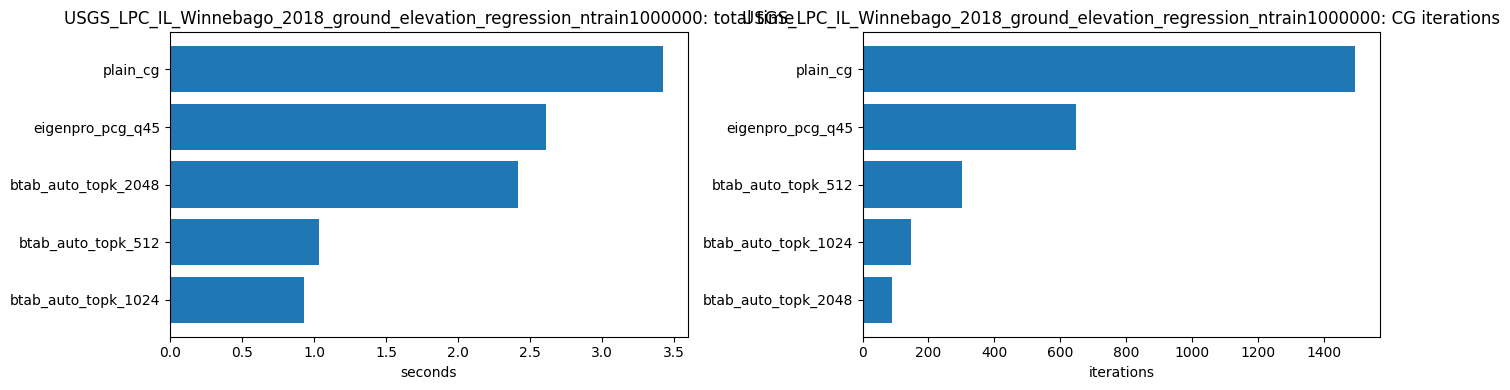

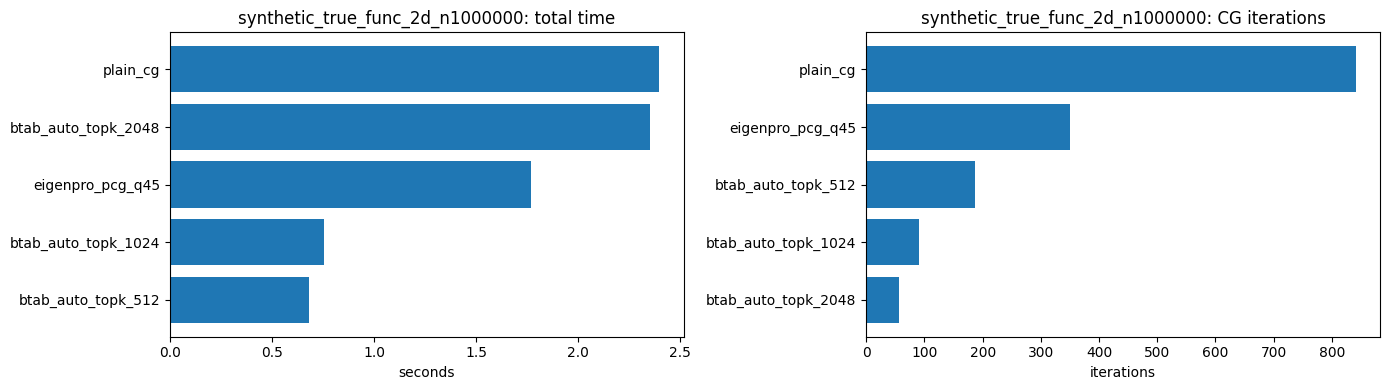

In [68]:
plot_df = df[df["status"] == "ok"].copy()
for dataset_stem, sub in plot_df.groupby("dataset_stem"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sub = sub.sort_values("time_total")
    axes[0].barh(sub["method"], sub["time_total"])
    axes[0].set_title(f"{dataset_stem}: total time")
    axes[0].set_xlabel("seconds")

    sub2 = sub.sort_values("cg_iters")
    axes[1].barh(sub2["method"], sub2["cg_iters"])
    axes[1].set_title(f"{dataset_stem}: CG iterations")
    axes[1].set_xlabel("iterations")
    plt.tight_layout()
    plt.show()

In [69]:
btab_df = df[df["method"].astype(str).str.contains("btab", case=False, na=False)].copy()
if not btab_df.empty:
    cols = [
        "dataset_stem",
        "method",
        "solve_mode",
        "exact_apply_mode",
        "outer_solver",
        "outer_gmres_restart",
        "box_size",
        "cg_iters",
        "t_precond_total",
        "t_precond_avg",
        "time_build_box_matrix",
        "time_cholesky",
        "time_build_inverse",
        "time_build_local_fft",
        "time_diag_total",
        "time_box_gather_total",
        "time_box_solve_total",
        "time_box_scatter_total",
        "time_diag_avg",
        "time_box_gather_avg",
        "time_box_solve_avg",
        "time_box_scatter_avg",
        "inner_total_iters",
        "inner_total_matvec",
        "inner_total_precond",
        "precond_apply_calls",
        "rmse_test",
    ]
    btab_summary = btab_df[[c for c in cols if c in btab_df.columns]].copy()
    display_full_df(btab_summary.sort_values(["dataset_stem", "method"]).reset_index(drop=True))
else:
    print("No BTAB rows found.")

,dataset_stem,method,solve_mode,exact_apply_mode,outer_solver,outer_gmres_restart,box_size,cg_iters,t_precond_total,t_precond_avg,time_build_box_matrix,time_cholesky,time_build_inverse,time_build_local_fft,time_diag_total,time_box_gather_total,time_box_solve_total,time_box_scatter_total,time_diag_avg,time_box_gather_avg,time_box_solve_avg,time_box_scatter_avg,inner_total_iters,inner_total_matvec,inner_total_precond,precond_apply_calls,rmse_test
0,USGS_LPC_IL_Winnebago_2018_ground_elevation_regression_ntrain1000000,btab_auto_topk_1024,exact,inverse,pcg,50.0,1369.0,148,0.080913,0.000547,0.043404,0.052286,0.259837,0.0,0.014196,0.010275,0.038978,0.011238,0.000096,0.000069,0.000263,0.000076,0.0,0.0,0.0,148.0,0.035779
1,USGS_LPC_IL_Winnebago_2018_ground_elevation_regression_ntrain1000000,btab_auto_topk_2048,exact,inverse,pcg,50.0,2601.0,90,0.093778,0.001042,0.173766,0.281597,1.511774,0.0,0.008080,0.005906,0.069643,0.006533,0.000090,0.000066,0.000774,0.000073,0.0,0.0,0.0,90.0,0.035779
2,USGS_LPC_IL_Winnebago_2018_ground_elevation_regression_ntrain1000000,btab_auto_topk_512,exact,inverse,pcg,50.0,625.0,301,0.120091,0.000399,0.007924,0.009935,0.030810,0.0,0.027721,0.020652,0.040312,0.019492,0.000092,0.000069,0.000134,0.000065,0.0,0.0,0.0,301.0,0.035779
3,synthetic_true_func_2d_n1000000,btab_auto_topk_1024,exact,inverse,pcg,50.0,1369.0,91,0.047382,0.000521,0.059430,0.052663,0.252234,0.0,0.008418,0.006427,0.023044,0.005688,0.000093,0.000071,0.000253,0.000063,0.0,0.0,0.0,91.0,0.001249
4,synthetic_true_func_2d_n1000000,btab_auto_topk_2048,exact,inverse,pcg,50.0,2601.0,57,0.059418,0.001042,0.195260,0.286659,1.541528,0.0,0.005021,0.003655,0.044395,0.004046,0.000088,0.000064,0.000779,0.000071,0.0,0.0,0.0,57.0,0.001248
5,synthetic_true_func_2d_n1000000,btab_auto_topk_512,exact,inverse,pcg,50.0,625.0,186,0.071060,0.000382,0.011530,0.009335,0.031120,0.0,0.016049,0.011744,0.024270,0.012065,0.000086,0.000063,0.000130,0.000065,0.0,0.0,0.0,186.0,0.001249


In [ ]:
# ---- Optional Colab export / download / disconnect ----
# 在 Colab 中把当前 run 的输出、当前 notebook 和 manifest 打成 zip，
# 同步到 Google Drive，并可触发浏览器下载，最后按需自动断开 runtime。
import json as _json
import shutil as _shutil
import time as _time
from datetime import timedelta
from pathlib import Path

IS_COLAB = "google.colab" in sys.modules
ENABLE_COLAB_EXPORT = True

if not (IS_COLAB and ENABLE_COLAB_EXPORT):
    print("[note] export cell skipped (IS_COLAB=", IS_COLAB, ", ENABLE_COLAB_EXPORT=", ENABLE_COLAB_EXPORT, ")")
else:
    try:
        from google.colab import drive, files, runtime
        _HAS_COLAB_EXPORT = True
    except Exception:
        drive = None
        files = None
        runtime = None
        _HAS_COLAB_EXPORT = False

    end_time = _time.time()
    try:
        elapsed_total = end_time - start_time
        time_str = str(timedelta(seconds=int(elapsed_total)))
    except NameError:
        time_str = "unknown (start_time was not set)"

    if "OUTPUT_PATH" in globals() and OUTPUT_PATH is not None:
        out_dir_path = Path(OUTPUT_PATH).resolve()
    else:
        if "OUT_ROOT" in globals():
            candidate_out_root = Path(OUT_ROOT).resolve()
        elif "REPO_ROOT" in globals():
            candidate_out_root = (
                Path(REPO_ROOT).resolve()
                / "efgp_eigenpro_py"
                / "gpu"
                / "box_toeplitz_active_block"
                / "outputs"
            )
        else:
            candidate_out_root = Path.cwd().resolve() / "outputs"

        run_dirs = [p for p in candidate_out_root.iterdir() if p.exists() and p.is_dir()] if candidate_out_root.exists() else []
        if not run_dirs:
            raise FileNotFoundError(f"No run directories found under {candidate_out_root}")
        out_dir_path = max(run_dirs, key=lambda p: p.stat().st_mtime)

    if "REPO_ROOT" in globals():
        repo_root_path = Path(REPO_ROOT).resolve()
    else:
        notebook_root = Path.cwd().resolve()
        search_roots = [
            notebook_root,
            *notebook_root.parents,
            Path("/content/EFGP-Eigenpro"),
            Path("/content"),
        ]
        repo_root_path = next((p for p in search_roots if (p / "efgp_eigenpro_py").exists()), None)
        if repo_root_path is None:
            raise FileNotFoundError("Could not locate repo root containing 'efgp_eigenpro_py'.")

    notebook_src_path = (
        repo_root_path
        / "efgp_eigenpro_py"
        / "gpu"
        / "box_toeplitz_active_block"
        / "report_results.ipynb"
    ).resolve()

    drive_mount_dir = Path(globals().get("DRIVE_MOUNT_DIR", Path("/content/drive")))
    drive_mydrive_dir = Path(globals().get("DRIVE_MYDRIVE_DIR", drive_mount_dir / "MyDrive"))
    if not drive_mydrive_dir.exists() and drive is not None:
        try:
            drive.mount(str(drive_mount_dir))
        except Exception as e:
            print("Drive mount retry skipped:", e)

    if not drive_mydrive_dir.exists():
        raise FileNotFoundError(
            "Google Drive is not mounted. Run the 'Colab / Drive setup' cell first and ensure MyDrive is available."
        )

    if "DRIVE_OUTPUT_DIR" in globals():
        drive_output_dir = Path(DRIVE_OUTPUT_DIR)
    else:
        drive_output_dir = drive_mydrive_dir / "EFGP_Eigenpro" / "benchmark_exports"
    drive_output_dir.mkdir(parents=True, exist_ok=True)

    zip_name = f"{out_dir_path.name}_bundle.zip"
    export_root = out_dir_path.parent / f"{out_dir_path.name}_export_bundle"
    zip_base = out_dir_path.parent / f"{out_dir_path.name}_bundle"
    zip_path = Path(f"{zip_base}.zip")
    target_drive_path = drive_output_dir / zip_name

    required_checks = {
        "out_dir_exists": out_dir_path.exists(),
        "notebook_exists": notebook_src_path.exists(),
        "summary_csv_exists": (out_dir_path / "summary.csv").exists(),
        "experiment_config_exists": (out_dir_path / "experiment_config.json").exists(),
    }
    print("artifact checks:", _json.dumps({k: bool(v) for k, v in required_checks.items()}, indent=2))
    missing = [k for k, v in required_checks.items() if not bool(v)]
    if missing:
        raise FileNotFoundError("Missing required artifacts: " + ", ".join(missing))

    if export_root.exists():
        _shutil.rmtree(export_root)
    export_root.mkdir(parents=True, exist_ok=True)

    export_results_dir = export_root / out_dir_path.name
    _shutil.copytree(out_dir_path, export_results_dir)

    notebook_dst_dir = export_root / "notebook"
    notebook_dst_dir.mkdir(parents=True, exist_ok=True)
    notebook_dst_path = notebook_dst_dir / notebook_src_path.name
    if notebook_src_path.exists():
        _shutil.copy2(notebook_src_path, notebook_dst_path)

    export_manifest = {
        "run_tag": out_dir_path.name,
        "elapsed": time_str,
        "export_root": str(export_root),
        "out_dir": str(out_dir_path),
        "notebook_src": str(notebook_src_path),
        "drive_output_dir": str(drive_output_dir),
        "github_notebook_url": globals().get("GITHUB_NOTEBOOK_URL", ""),
        "colab_notebook_url": globals().get("COLAB_NOTEBOOK_URL", ""),
        "includes": [
            str(export_results_dir),
            str(notebook_dst_path) if notebook_src_path.exists() else "notebook_missing",
        ],
    }
    (export_root / "export_manifest.json").write_text(
        _json.dumps(export_manifest, indent=2, ensure_ascii=False),
        encoding="utf-8",
    )

    if zip_path.exists():
        zip_path.unlink()
    print(f"Packing export bundle: {export_root}")
    _shutil.make_archive(str(zip_base), "zip", root_dir=str(export_root.parent), base_dir=export_root.name)
    print("zip saved:", zip_path)

    print(f"Copying zip to Google Drive: {target_drive_path}")
    try:
        _shutil.copy2(zip_path, target_drive_path)
    except Exception as e:
        print("Drive copy failed:", e)

    local_ok = zip_path.exists() and zip_path.stat().st_size > 0
    drive_ok = target_drive_path.exists() and target_drive_path.stat().st_size > 0
    print("local zip ok:", local_ok)
    print("drive zip ok:", drive_ok)

    if local_ok:
        if _HAS_COLAB_EXPORT and files is not None:
            print("Starting browser backup download...")
            files.download(str(zip_path))
        else:
            print("Not in Colab; browser download skipped.")

    print("-" * 30)
    print("Experiment status:", "completed and backed up" if drive_ok else "local zip ok, Drive sync failed")
    print("Elapsed:", time_str)
    print("OUT_DIR:", out_dir_path)
    print("Local zip:", zip_path)
    print("Drive zip:", target_drive_path)
    print("-" * 30)

    if drive_ok and _HAS_COLAB_EXPORT and runtime is not None:
        print("Disconnecting Colab runtime in 20 seconds to save GPU quota...")
        _time.sleep(20)
        runtime.unassign()
    elif not drive_ok:
        print("Drive sync check failed; automatic disconnect cancelled.")
